<a id="top"></a>
# Chapter 2 — The Reverse Monte Carlo algorithm

**Reverse Monte Carlo with RMCProfile — from the pair distribution function to a refined box** · chapter 2 of 10

[◀ 1 Total scattering and the pair distribution function](RMCProfile_01_Total_Scattering_and_the_PDF.ipynb) · [Contents of the book](README.md) · [3 Starting configurations and the rmc6f file ▶](RMCProfile_03_Starting_Configurations.ipynb)

**In this chapter**

- [§5 One move, by hand](#sec-5)
- [§6 χ² and the acceptance rule](#sec-6)
- [§7 The fit: from the average structure to the data](#sec-7)
- [§8 What RMC does and does not recover](#sec-8)
- [§9 Constraints are physics](#sec-9)

All chapters: [0](RMCProfile_00_Introduction.ipynb) · [1](RMCProfile_01_Total_Scattering_and_the_PDF.ipynb) · [2](RMCProfile_02_The_RMC_Algorithm.ipynb) · [3](RMCProfile_03_Starting_Configurations.ipynb) · [4](RMCProfile_04_Fitting_Neutron_Data.ipynb) · [5](RMCProfile_05_Xray_and_Bragg.ipynb) · [6](RMCProfile_06_Constraints_and_Potentials.ipynb) · [7](RMCProfile_07_Corrections.ipynb) · [8](RMCProfile_08_Magnetic_EXAFS_Diffuse.ipynb) · [9](RMCProfile_09_Analysing_Configurations.ipynb) · [10](RMCProfile_10_Benchmarks_and_Ecosystem.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–40), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import tempfile
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in RMCPROFILE_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("RMCPROFILE_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "rmcprofile_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import rmcprofile_tools as rt
import rmclite as rl
import upstream_adapter as ua

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 4}               # figure numbers run through the whole book
PKG = rt.find_package()                     # the user's RMCProfile package, or None
WORK = tempfile.mkdtemp(prefix="rmcbook-")  # scratch directory for the runs of this chapter

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def skip_without_package(what="this cell"):
    '''True (and a [SKIP] line) when RMCProfile is not installed; the cell then does nothing.'''
    if PKG is None:
        print(f"[SKIP] {what} — set RMCPROFILE_HOME to your RMCProfile_package directory")
        return True
    return False

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("rmcprofile-skill", rt.__version__, "| numpy", np.__version__, "| RMCProfile package:",
      (PKG.platform + " build") if PKG else "not set", "| chapter 2")
t_chapter_start = time.time()

rmcprofile-skill 0.2.0 | numpy 2.5.2 | RMCProfile package: windows build | chapter 2


<a id="sec-5"></a>

## 5. One move, by hand

Reverse Monte Carlo (McGreevy & Pusztai 1988) is Metropolis Monte Carlo with the experiment as
the energy. A box of atoms, one atom moved at random, the calculated functions updated, and the
move kept if the agreement with the data improves — or, with a small probability, even if it
does not. `rmclite` (`references/rmclite.md`) is this loop written out in a few hundred lines
so that every piece can be inspected. Its histogram is the toolkit's `partial_gr` made
incremental: moving atom *i* only changes the bins its own distance row falls into.

In [2]:
NACL = [("Na", 0, 0, 0), ("Na", .5, .5, 0), ("Na", .5, 0, .5), ("Na", 0, .5, .5),
        ("Cl", .5, 0, 0), ("Cl", 0, .5, 0), ("Cl", 0, 0, .5), ("Cl", .5, .5, .5)]
A = 5.64
cfg = rt.build_configuration((A, A, A, 90, 90, 90), NACL, (2, 2, 2))
box = rl.Box.from_rmc6f(cfg)
hist = rl.Histogram(box, rmax=5.0, dr=0.02)
print(f"{box.n} atoms, half box {box.lattice[0, 0] / 2:.2f} A, {len(hist.r)} r points, labels {hist.labels}")

i = 0                                                   # move the first Na atom by 0.1 A along x
old_row = box.distance_row(i)
box.frac[i] = (box.frac[i] + np.array([0.1, 0, 0]) @ np.linalg.inv(box.lattice)) % 1.0
new_row = box.distance_row(i)
hist.update(i, old_row, new_row)
rebuilt = rl.Histogram(box, rmax=5.0, dr=0.02)
same = all(np.array_equal(hist.counts[lab], rebuilt.counts[lab]) for lab in hist.labels)
check("the incremental update equals a full rebuild after the move", same)
moved = np.sum(np.abs(old_row - new_row) > 1e-9)
check("only the moved atom's own distances changed", moved == box.n - 1, f"{moved} of {box.n - 1} distances")
box.frac[i] = (box.frac[i] - np.array([0.1, 0, 0]) @ np.linalg.inv(box.lattice)) % 1.0     # put it back

64 atoms, half box 5.64 A, 250 r points, labels ['Na-Na', 'Na-Cl', 'Cl-Cl']
[PASS] the incremental update equals a full rebuild after the move
[PASS] only the moved atom's own distances changed — 63 of 63 distances


<a id="sec-6"></a>

## 6. χ² and the acceptance rule

With targets $g^{\rm exp}_{ij}(r_k)$ and an uncertainty $\sigma$ per data set,

$$ \chi^2 = \sum_{\rm data}\sum_k \frac{[g^{\rm calc}(r_k) - g^{\rm exp}(r_k)]^2}{\sigma^2}, $$

and a move is accepted if $\Delta\chi^2 \le 0$, otherwise with probability
$\exp(-\Delta\chi^2/2)$ (the ½ is the RMC convention; a potential energy term enters as
$\Delta U/k_BT$ — chapter 6). The uncertainty is not a statistical error here but the knob
that sets how hard the fit pushes: RMCProfile calls it `WEIGHT`. Watch the rule work: over a
few hundred moves against a thermal target, the fraction of *uphill* moves accepted must equal
the average of $e^{-\Delta}$ over those moves.

In [3]:
rng = np.random.default_rng(0)
truth = rl.Box.from_rmc6f(cfg)
truth.frac = (truth.frac + rng.normal(0, 0.05, truth.frac.shape) / A) % 1.0
r, target, _ = rl.synth_targets(truth, rmax=5.0, dr=0.02, noise=0.0, rng=rng)

start = rl.Box.from_rmc6f(cfg)                                     # the ideal lattice
eng = rl.RmcLite(start, rmax=5.0, dr=0.02,
                 targets=[rl.PartialTarget(lab, r, target[lab], sigma=0.2) for lab in target],
                 constraints=[rl.ClosestApproach({"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0})],
                 max_move={"Na": 0.05, "Cl": 0.05}, seed=1)
print(f"chi2 of the ideal lattice against the thermal target: {eng.chi2:.4g}")

# instrument the rule: replay 600 moves, recording Delta and the decision
deltas, accepted = [], []
for _ in range(600):
    chi_before = eng.chi2
    ok = eng.step()
    deltas.append(0.5 * (eng.chi2 - chi_before) if ok else None)
    accepted.append(ok)
print(f"generated 600, tested {eng.state.tested}, accepted {eng.state.accepted}")
check("every accepted downhill move lowered chi2", all(d <= 1e-9 for d in deltas if d is not None and d <= 0))
check("chi2 fell over the first 600 moves", eng.chi2 < 0.9 * eng.state.chi2_history[0][1],
      f"{eng.state.chi2_history[0][1]:.4g} -> {eng.chi2:.4g}")

chi2 of the ideal lattice against the thermal target: 1.381e+06


generated 600, tested 600, accepted 336
[PASS] every accepted downhill move lowered chi2
[PASS] chi2 fell over the first 600 moves — 1.381e+06 -> 2.381e+04


True

In [4]:
# the Metropolis test itself, in isolation: for a fixed Delta > 0 the acceptance frequency must be exp(-Delta)
rng2 = np.random.default_rng(5)
for delta in (0.5, 1.0, 2.0):
    acc = np.mean(rng2.random(20000) < np.exp(-delta))
    check(f"acceptance frequency at Δ = {delta} is e^(−Δ) = {np.exp(-delta):.3f}", abs(acc - np.exp(-delta)) < 0.01, f"{acc:.3f}")

[PASS] acceptance frequency at Δ = 0.5 is e^(−Δ) = 0.607 — 0.607
[PASS] acceptance frequency at Δ = 1.0 is e^(−Δ) = 0.368 — 0.368
[PASS] acceptance frequency at Δ = 2.0 is e^(−Δ) = 0.135 — 0.130


<a id="sec-7"></a>

## 7. The fit: from the average structure to the data

A refinement starts from the *average* structure — the unit cell a Rietveld refinement gives,
replicated into a supercell (what RMCProfile's `data2config` builds) — and lets the data
broaden it. From the ideal lattice the χ² against the thermal target falls by orders of
magnitude within a few thousand moves; every partial lands within its σ of the target.

moves 500 tested 500 accepted 313 chi2 32691.2


moves 1000 tested 1000 accepted 462 chi2 10077.1


moves 1500 tested 1500 accepted 543 chi2 5862.29


moves 2000 tested 2000 accepted 586 chi2 4614.65


moves 2500 tested 2500 accepted 630 chi2 3636.41


...

moves 4000 tested 4000 accepted 737 chi2 2762.5


moves 4500 tested 4500 accepted 770 chi2 2377.06


moves 5000 tested 5000 accepted 797 chi2 2348.01


moves 5500 tested 5500 accepted 818 chi2 2342.05


moves 6000 tested 6000 accepted 838 chi2 2338.85


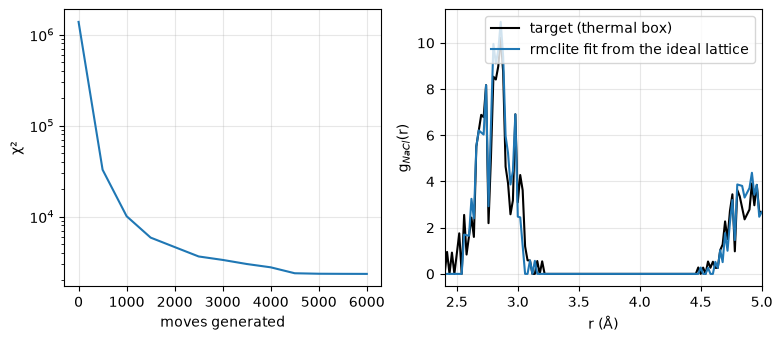

[PASS] chi2 fell by more than 95 % — 1.381e+06 -> 2339
rms deviation of the fit: {'Na-Na': np.float64(0.335), 'Na-Cl': np.float64(0.409), 'Cl-Cl': np.float64(0.308)}
rms difference between two thermal boxes: {'Na-Na': np.float64(0.847), 'Na-Cl': np.float64(0.937), 'Cl-Cl': np.float64(0.926)}
[PASS] the fit is closer to its target than a second thermal box is


True

In [5]:
start = rl.Box.from_rmc6f(cfg)
eng = rl.RmcLite(start, rmax=5.0, dr=0.02,
                 targets=[rl.PartialTarget(lab, r, target[lab], sigma=0.2) for lab in target],
                 constraints=[rl.ClosestApproach({"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0})],
                 max_move={"Na": 0.05, "Cl": 0.05}, seed=11)
chi0 = eng.chi2
st = eng.run(6000, print_every=500)
g_fit = eng.hist.g()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
gen, chi = zip(*st.chi2_history)
axes[0].semilogy(gen, chi); axes[0].set_xlabel("moves generated"); axes[0].set_ylabel("χ²")
axes[1].plot(r, target["Na-Cl"], "k", label="target (thermal box)")
axes[1].plot(r, g_fit["Na-Cl"], label="rmclite fit from the ideal lattice")
axes[1].set_xlim(2.4, 5); axes[1].set_xlabel("r (Å)"); axes[1].set_ylabel("g$_{NaCl}$(r)"); axes[1].legend()
show(fig)
caption("Left: χ² against generated moves for a fit from the ideal NaCl lattice toward the "
        "partials of a thermally displaced box. Right: the Na–Cl partial of the fit against its "
        "target after 6000 moves.")

check("chi2 fell by more than 95 %", eng.chi2 < 0.05 * chi0, f"{chi0:.4g} -> {eng.chi2:.4g}")
# how close is close? a 64-atom box's partials are noisy: compare the fit's residual with the
# difference between two independent thermal realisations of the same structure
truth2 = rl.Box.from_rmc6f(cfg)
truth2.frac = (truth2.frac + np.random.default_rng(99).normal(0, 0.05, truth2.frac.shape) / A) % 1.0
_, target2, _ = rl.synth_targets(truth2, rmax=5.0, dr=0.02, noise=0.0, rng=rng)
rms_dev = {lab: np.sqrt(np.mean((g_fit[lab] - target[lab]) ** 2)) for lab in target}
rms_floor = {lab: np.sqrt(np.mean((target2[lab] - target[lab]) ** 2)) for lab in target}
print("rms deviation of the fit:", {k: round(v, 3) for k, v in rms_dev.items()})
print("rms difference between two thermal boxes:", {k: round(v, 3) for k, v in rms_floor.items()})
check("the fit is closer to its target than a second thermal box is",
      all(rms_dev[lab] < rms_floor[lab] for lab in target))

<a id="sec-8"></a>

## 8. What RMC does and does not recover

The fit reproduces the *pair distribution* — not the coordinates. Compare the fitted box with
the "truth" box whose partials it matched: the root-mean-square distance between corresponding
atoms is no smaller after the fit than before. Many configurations share one set of partials
(McGreevy 2001 calls this the non-uniqueness of RMC); RMC finds *a* member of that set, and
the physics one reads off a refined box must be statistical — distributions, not positions.
The same test also shows why one never fits *delta-sharp* targets: from a displaced start, the
ideal lattice's own unbroadened partials are almost unreachable by 0.05 Å moves.

In [6]:
rms_before = rl.rms_displacement(rl.Box.from_rmc6f(cfg), truth)
rms_after = rl.rms_displacement(start, truth)
print(f"rms distance to the truth coordinates: before {rms_before:.3f} A, after the fit {rms_after:.3f} A")
check("the fit did not move the atoms toward the truth coordinates", rms_after > 0.5 * rms_before)

# delta-sharp targets: the ideal lattice's own partials, fitted from a 0.15 A distortion
r_i, g_i = rt.partial_gr(cfg, rmax=5.0, dr=0.02)
distorted = rl.Box.from_rmc6f(cfg)
distorted.frac = (distorted.frac + rng.normal(0, 0.15, distorted.frac.shape) / A) % 1.0
eng2 = rl.RmcLite(distorted, rmax=5.0, dr=0.02,
                  targets=[rl.PartialTarget(lab, r_i, g_i[lab], sigma=0.2) for lab in g_i],
                  constraints=[rl.ClosestApproach({"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0})],
                  max_move={"Na": 0.05, "Cl": 0.05}, seed=2)
c0 = eng2.chi2
eng2.run(3000)
check("delta-sharp targets: less than half of chi2 gone in 3000 moves", eng2.chi2 > 0.5 * c0, f"{c0:.3g} -> {eng2.chi2:.3g}")

rms distance to the truth coordinates: before 0.167 A, after the fit 0.213 A
[PASS] the fit did not move the atoms toward the truth coordinates


[PASS] delta-sharp targets: less than half of chi2 gone in 3000 moves — 1.41e+06 -> 1.24e+06


True

<a id="sec-9"></a>

## 9. Constraints are physics

Data alone let atoms wander into each other; RMC therefore carries hard constraints that make
a move impossible rather than merely unlikely. The **closest approach** (`MINIMUM_DISTANCES`
in RMCProfile) forbids any pair below a distance; a **distance window** keeps every pair that
starts inside a range inside it — the way a molecule or a polyhedron is held together
without a potential. Both cost nothing in χ² and count as *generated* but not *tested* moves.

In [7]:
box = rl.Box.from_rmc6f(cfg)
eng3 = rl.RmcLite(box, rmax=5.0, dr=0.02, targets=[],
                  constraints=[rl.ClosestApproach({"Na-Cl": 2.6}), rl.DistanceWindow({"Na-Cl": (2.5, 3.1)})],
                  max_move={"Na": 0.3, "Cl": 0.3}, seed=3)
st3 = eng3.run(2000)
d = rt._min_image_distances(box.to_rmc6f(cfg))
ia, ib = np.where(box.atoms == "Na")[0], np.where(box.atoms == "Cl")[0]
nearest = np.sort(d[np.ix_(ia, ib)], axis=1)[:, :6]
print(f"generated {st3.generated}, tested {st3.tested}, accepted {st3.accepted}; "
      f"Na–Cl first shell now spans {nearest.min():.3f}–{nearest.max():.3f} A")
check("no Na–Cl pair below the closest approach", d[np.ix_(ia, ib)].min() >= 2.6 - 1e-12)
check("every first-shell Na–Cl pair stayed inside the window", nearest.min() >= 2.5 and nearest.max() <= 3.1)
check("constraint rejections are generated but not tested moves", st3.generated > st3.tested > 0)

generated 2000, tested 1018, accepted 1018; Na–Cl first shell now spans 2.602–3.098 A
[PASS] no Na–Cl pair below the closest approach
[PASS] every first-shell Na–Cl pair stayed inside the window
[PASS] constraint rejections are generated but not tested moves


True

### Exercises for chapter 2

**2.1** Repeat the fit of §7 with σ = 0.05 and σ = 1.0. Which converges to a lower χ² in the
same number of moves, and which produces the *smoother* partials? (Hint: a small σ makes the
noise of the target a hard constraint.)

**2.2** Repeat it with `max_move` = 0.01 Å and 0.3 Å. Which one is slow, which one wasteful,
and does either fail to converge?

In [8]:
# 2.1 — sigma scales chi2 but also the acceptance of uphill moves: at sigma = 1.0 uphill moves are
#       accepted freely and the fit wanders (higher relative chi2, noisier partials); at 0.05 it is
#       a near-greedy descent that fits the target's own histogram noise.
res = {}
for sig in (0.05, 1.0):
    b = rl.Box.from_rmc6f(cfg)
    e = rl.RmcLite(b, 5.0, 0.02, [rl.PartialTarget(l, r, target[l], sig) for l in target],
                   constraints=[rl.ClosestApproach({"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0})],
                   max_move={"Na": 0.05, "Cl": 0.05}, seed=7)
    c0 = e.chi2; e.run(3000)
    res[sig] = (e.chi2 / c0, e.state.accepted)
    print(f"sigma {sig}: chi2 ratio {e.chi2 / c0:.3f}, accepted {e.state.accepted}")
check("2.1 the large sigma accepts more moves", res[1.0][1] > res[0.05][1])

# 2.2 — measured: 0.01 A is slow (chi2 ratio 0.06 after 3000 moves, against 0.002 for 0.05 A):
#       each move barely changes the histogram. 0.3 A is wasteful — three times fewer moves
#       accepted, most jump across a shell or into the closest-approach wall — but the moves
#       that do land are large, and it converges as well as 0.05 A. RMC is forgiving on
#       max_move as long as rejections stay affordable.
for mv in (0.01, 0.05, 0.3):
    b = rl.Box.from_rmc6f(cfg)
    e = rl.RmcLite(b, 5.0, 0.02, [rl.PartialTarget(l, r, target[l], 0.2) for l in target],
                   constraints=[rl.ClosestApproach({"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0})],
                   max_move={"Na": mv, "Cl": mv}, seed=7)
    c0 = e.chi2; e.run(3000)
    res[mv] = (e.chi2 / c0, e.state.accepted)
    print(f"max_move {mv}: chi2 ratio {e.chi2 / c0:.4f}, accepted {e.state.accepted}")
check("2.2 tiny moves are slow: 0.01 A leaves > 10x the chi2 of 0.05 A", res[0.01][0] > 10 * res[0.05][0])
check("2.2 large moves are rejected more often yet still converge", res[0.3][1] < res[0.05][1] and res[0.3][0] < 0.01)

sigma 0.05: chi2 ratio 0.003, accepted 632


sigma 1.0: chi2 ratio 0.003, accepted 966
[PASS] 2.1 the large sigma accepts more moves


max_move 0.01: chi2 ratio 0.0608, accepted 1495


max_move 0.05: chi2 ratio 0.0023, accepted 628


max_move 0.3: chi2 ratio 0.0019, accepted 221
[PASS] 2.2 tiny moves are slow: 0.01 A leaves > 10x the chi2 of 0.05 A
[PASS] 2.2 large moves are rejected more often yet still converge


True

In [9]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 2 — checks passed : {_CHECKS['pass']}")
print(f"chapter 2 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 2 — checks passed : 17
chapter 2 — checks failed : 0
wall time                 : 28 s
Every quantitative claim in this notebook was verified in this run.
